# **Personalized Movie Recommendation System Using Hybrid Approaches**

---





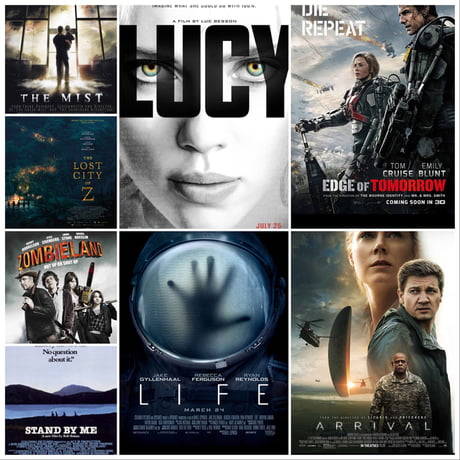

# **Project Overview**

---



This project develops a **movie recommendation system** designed to improve user engagement and satisfaction on a streaming platform. The primary stakeholder is a product manager seeking to enhance personalized content delivery using user interaction data. The dataset consists of two main sources: a ratings dataset containing user-movie interactions and a movies dataset providing metadata such as titles and genres. These datasets are well-suited for the problem as they capture both user preferences and item characteristics, enabling multiple recommendation strategies.


Three recommendation models were implemented. A popularity-based model provided a baseline by recommending highly rated movies. A content-based filtering model used genre similarity to suggest similar items. Finally, a collaborative filtering model leveraged user rating patterns to generate personalized recommendations. The collaborative filtering approach was implemented using advanced techniques suitable for recommendation systems.




#**Problem Statement**

---




Endless scrolling is the enemy of enjoyment. When users can't decide what to watch, their engagement drops and streaming platforms face the risk of lower customer retention.

Our challenge is to transform this experience. Instead of presenting users with an overwhelming catalog, we need to provide them with a personalized shortlist. This project focuses on building a recommendation engine that does exactly that, predicting user preferences to deliver a top-five list of tailored suggestions, making discovery effortless and viewing more satisfying.

**Specific Objectives:**

* To explore and preprocess the MovieLens dataset to understand user–movie interaction patterns.

* To implement a collaborative filtering model that predicts movie ratings based on user or item similarity.

* To evaluate the performance of the recommendation model using appropriate metrics such as RMSE or MAE.

* To demonstrate how the recommendation system can be applied in a streaming platform to improve user experience and retention.

**Research Questions:**

* What patterns can be identified in the MovieLens dataset regarding user–movie interactions?

* How can collaborative filtering be used to predict user ratings for movies they haven’t seen?

* How accurately does the model predict user ratings when evaluated using RMSE or MAE metrics?

* How can implementing a recommendation system improve user satisfaction and retention for a streaming service?

#Success Criteria

---


* Achieve RMSE ≤ 0.90 and MAE ≤ 0.70 on test data.
* Generate meaningful, personalized recommendations.

## Model Evaluation

---



**Model evaluation** was conducted using appropriate validation strategies, including train-test splitting and performance metrics such as RMSE for rating prediction. Additionally, qualitative evaluation was performed by examining recommendation outputs. The final model demonstrated the ability to generate relevant and personalized recommendations. Limitations include data sparsity and cold-start problems. Future improvements could involve incorporating additional user or item features to enhance performance.

# **Data Understanding**

---



We are using the MovieLens Small Dataset, which contains:

 * 100,000 movie ratings
 *   600+ users
 * 9,000+ unique movies

The data includes user IDs, movie IDs, ratings, and movie metadata (titles, genres, tags).

We have several libraries and tools that are going to be used such as advanced CF algorithims (SVD).

Dataset, Reader, SVD, train_test_split, accuracy, GridSearchCV are going to be used for building and evaluating the matrix factorization component.

TF-IDF and cosine_similarity, will be used to build the Content-Based Filtering component based on movie genres.Lastly,the final model will be serialized for deployment.

# **Data Preperation**

---




* Data preparation in this project involved cleaning and combining the ratings and movies datasets so they could be used for recommendation modeling. The datasets were merged using the movieId column, then checked for missing values and duplicates to ensure data quality. Unnecessary columns were removed, and low-activity users or rarely rated movies were filtered where needed to improve the performance of the recommendation system. This prepared the data for building popularity-based, content-based, and collaborative filtering models.

In [ ]:
#importing the libraries
#!pip uninstall -y numpy
#!pip install "numpy<2"
!pip install scikit-surprise
import pandas as pd
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split as sklearn_train_test_split, GridSearchCV as sklearn_GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, silhouette_score
from scipy.sparse.linalg import svds
from scipy.sparse import csc_matrix
from surprise.model_selection import cross_validate, GridSearchCV
from surprise.model_selection import GridSearchCV
from surprise import accuracy
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split, GridSearchCV as surprise_GridSearchCV

The ratings.csv and movies.csv files are loaded into Pandas DataFrames.

Shape Inspection: The size of the raw datasets is printed, confirming we are starting with 100,836 ratings and 9,742 movies.

Merging: The ratings data is merged with the necessary title and genres information from the movies data using movieId as the common key. This creates a single DataFrame (ratings_merged) containing all user-item-rating details along with the movie's descriptive features.

Preview: The first 10 rows of the merged data are displayed for a quick verification of the merge operation

In [6]:
#loading the dataset (movies)
movies = pd.read_csv("movies.csv")
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [7]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB


In [3]:
#loading the dataset (ratings)
ratings = pd.read_csv('ratings.csv')
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [4]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


# Data Cleaning

### Checked for null and duplicate values

In [7]:
movies.isna().sum()

,0
movieId,0
title,0
genres,0


In [8]:
ratings.isna().sum()

,0
userId,0
movieId,0
rating,0
timestamp,0


In [9]:
movies.duplicated().sum()

0

In [10]:
ratings.duplicated().sum()

0

* The dataset is complete with no missing values, reducing preprocessing overhead.

In [11]:
merged = ratings.merge(movies, on='movieId') # merge the two datasets
merged.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [12]:
# droping the timestamp column
merged = merged.drop(columns=['timestamp'])


## Filter weak data

Remove:
  * movies with very few ratings
*   users with very few ratings

In [13]:
movie_counts = merged['movieId'].value_counts()
movie_counts.head()
user_counts = merged['userId'].value_counts()

merged = merged[merged['movieId'].isin(movie_counts[movie_counts > 50].index)]
merged = merged[merged['userId'].isin(user_counts[user_counts > 50].index)]


# **Exploratory Data Analysis (EDA)**

---



**Dataset Size:**

Users: 610 unique users.

Items (Movies): 9,724 unique movies.

Note: The user-entered code accidentally printed the user count for items, but the movieId unique count is 9,724 based on the movies.csv file structure.

Interactions: 100,836 total ratings.

**User Activity (Interactions per User):**

The average user has provided 165.7 ratings, which is quite high.

Min: 20 ratings (Confirming the MovieLens condition that all included users have rated at least 20 movies).

Max: 7,376 ratings (Indicating a few highly active "super-users").

**Rating Distribution:**

* The ratings are centered around the high end, with a median and mean rating of 4.0.Mean Rating: 3.501 (Out of 5.0)Std Dev: 1.043These statistics confirm the data is from a relatively small but highly active group of users, and ratings are generally positive.

In [14]:
#Number of Users,Items and interactions
n_users= ratings['userId'].nunique()
n_items= ratings['movieId'].nunique()
print(f'Users: {n_users}, Items: {n_users}, Interactions: {len(ratings)}')
#Count Interactions per user
user_counts= ratings.groupby('userId').size().describe()
print(user_counts)
# ratings distribution
ratings['rating'].describe()

Users: 610, Items: 610, Interactions: 100836
count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
dtype: float64


,rating
count,100836.000000
mean,3.501557
std,1.042529
min,0.500000
25%,3.000000
50%,3.500000
75%,4.000000
max,5.000000


**data set overview**

Here, the following is computed about the dataset:

* The total number of ratings in the dataset.

* The number of unique movies that have been rated.

* The number of unique users who have provided ratings.

In [15]:
n_ratings = len(ratings)
n_movies = movies['movieId'].nunique()
n_users = ratings['userId'].nunique()

print(f'number of ratings: {n_ratings}')
print(f'number of movies: {n_movies}')
print(f'number of users: {n_users}')

number of ratings: 100836
number of movies: 9742
number of users: 610


# **Graphical Insights**

---



/tmp/ipython-input-26-3193237718.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='num_ratings', y='title', data=top_movies_df, palette='viridis')


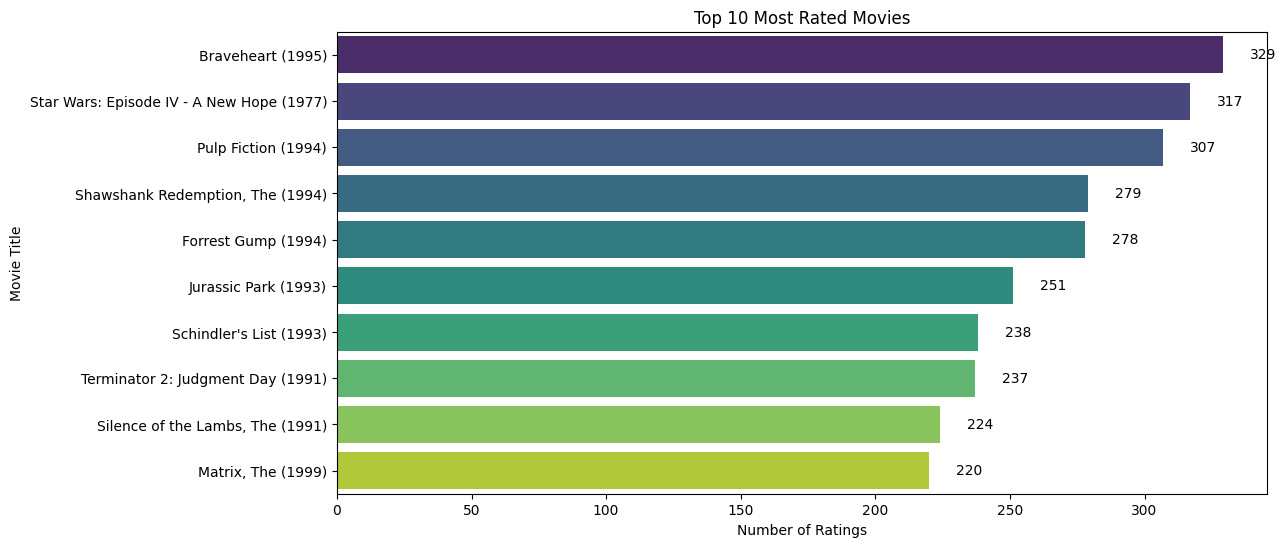

In [ ]:
# Top 10 most popular movies based on the number of user ratings.

# Get top 10 most rated movies
top_movies = ratings['movieId'].value_counts().head(10).index
top_movies_df = movies[movies['movieId'].isin(top_movies)].copy()
top_movies_df['num_ratings'] = ratings[ratings['movieId'].isin(top_movies)]['movieId'].value_counts().values

# Sort by number of ratings (descending)
top_movies_df = top_movies_df.sort_values('num_ratings', ascending=False)

# Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='num_ratings', y='title', data=top_movies_df, palette='viridis')

for i, v in enumerate(top_movies_df['num_ratings']):
    ax.text(v + 10, i, str(v), color='black', va='center')

plt.xlabel("Number of Ratings")
plt.ylabel("Movie Title")
plt.title("Top 10 Most Rated Movies")
plt.show()

* Classic films like The Shawshank Redemption, Pulp Fiction, and Star Wars: Episode IV – A New Hope dominate in rating count, indicating strong and widespread user engagement.

/tmp/ipython-input-28-175615858.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


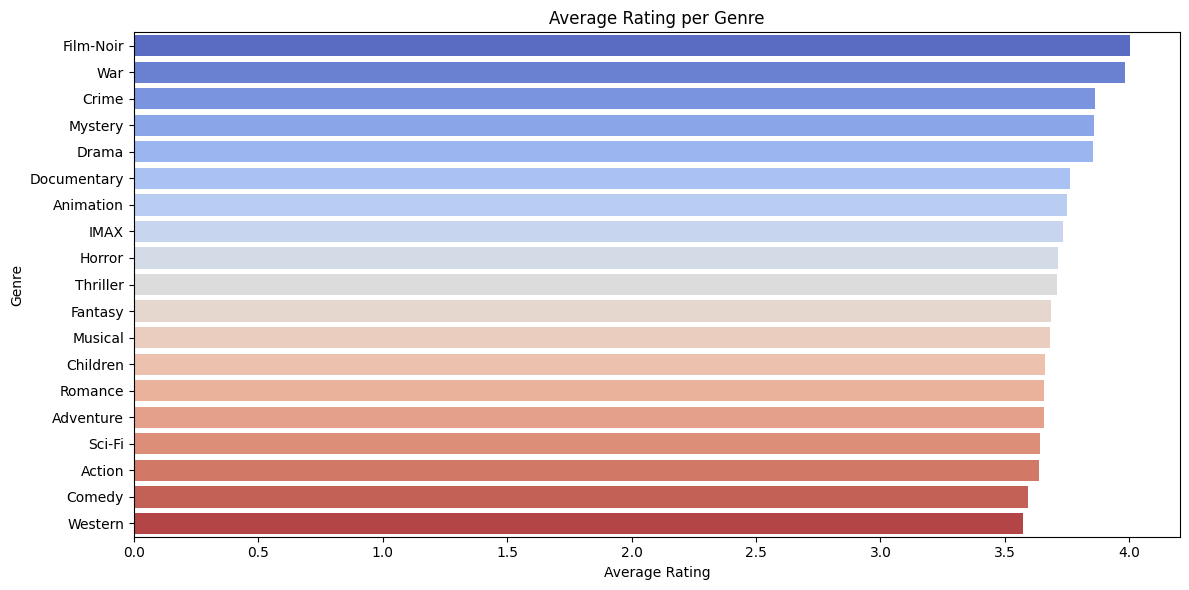

In [ ]:
# Average user ratings across different movie genres.

# Split and explode genres
merged = merged.assign(genres=merged["genres"].str.split("|")).explode("genres")

# Compute average rating per genre
genre_avg_ratings = (
    merged.groupby("genres")["rating"]
    .mean()
    .sort_values(ascending=False)
)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(
    x=genre_avg_ratings.values,
    y=genre_avg_ratings.index,
    palette="coolwarm"
)
plt.xlabel("Average Rating")
plt.ylabel("Genre")
plt.title("Average Rating per Genre")
plt.tight_layout()
plt.show()

* Genres like Film-Noir, War, and Crime receive the highest average ratings, suggesting users tend to rate these more critically acclaimed or niche genres more favorably than mainstream ones like Comedy and Action.

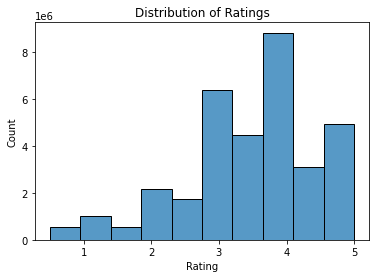

In [ ]:
#Rating distribution

plt.figure()
sns.histplot(ratings['rating'], bins=10)
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

* Most ratings are concentrated between 3 and 4, indicating that users generally give positive feedback to movies. Low ratings are relatively rare, suggesting a bias toward higher ratings in the dataset.

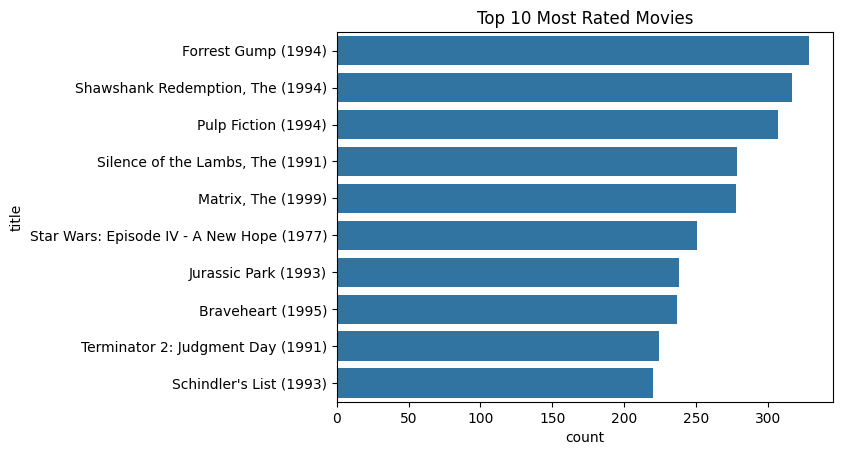

In [ ]:
#Most popular movies
top_movies = ratings['movieId'].value_counts().head(10)

top_movies = top_movies.reset_index()
top_movies.columns = ['movieId', 'count']

top_movies = top_movies.merge(movies, on='movieId')

import seaborn as sns
sns.barplot(x='count', y='title', data=top_movies)
plt.title("Top 10 Most Rated Movies")
plt.show()

* A small number of movies receive a very high number of ratings, indicating that popularity is highly skewed. This suggests that some movies dominate user attention, which is important for building a popularity-based recommendation system.

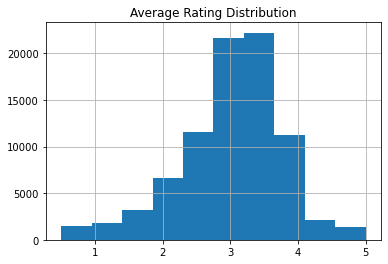

In [ ]:
#Average rating per movie
avg_rating = ratings.groupby('movieId')['rating'].mean()

avg_rating.hist()
plt.title("Average Rating Distribution")
plt.show()

* Most movies have average ratings between 2.5 and 4, indicating moderate to high user satisfaction. Very few movies have extremely low or extremely high average ratings.

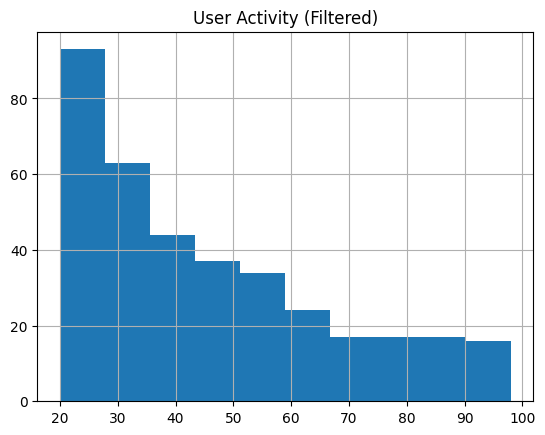

In [ ]:
#Number of ratings per user
user_counts = ratings['userId'].value_counts()

user_counts[user_counts < 100].hist()
plt.title("User Activity (Filtered)")
plt.show()

* Most users have rated only a small number of movies, while a few users are highly active. This indicates a sparse dataset, which can impact collaborative filtering performance.

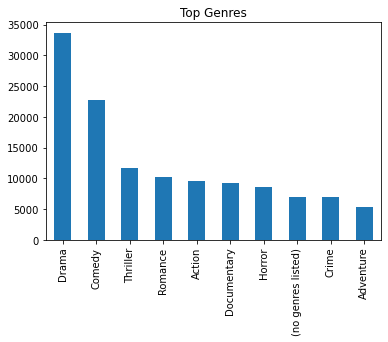

In [ ]:
#Genre analysis
movies['genres'] = movies['genres'].str.split('|')

from collections import Counter

all_genres = movies['genres'].explode()
genre_counts = Counter(all_genres)

pd.Series(genre_counts).sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Genres")
plt.show()

* Drama and Comedy are the most common genres, indicating that these categories dominate the dataset. This information is useful for content-based recommendation, as genre plays a key role in similarity between movies.

# **Machine Learning Methods**

---



## Popularity-Based Recommendation(baseline model)

The baseline model recommends movies based on their overall popularity and average ratings. This approach does not consider individual user preferences but provides a simple and effective starting point for comparison with more advanced models.

In [8]:
merged.head()

NameError: name 'merged' is not defined

In [17]:
#Calculating average rating and number of ratings for each movie
movie_stats = merged.groupby(['movieId', 'title']).agg(
    average_rating=('rating', 'mean'),
    number_of_ratings=('rating', 'count')
).reset_index()

movie_stats.head()

,movieId,title,average_rating,number_of_ratings
0,1,Toy Story (1995),3.884393,173
1,2,Jumanji (1995),3.436275,102
2,3,Grumpier Old Men (1995),3.255814,43
3,6,Heat (1995),3.928571,91
4,7,Sabrina (1995),3.184211,38


In [18]:
#Filtering movies with at least 50 ratings
popular_movies = movie_stats[movie_stats['number_of_ratings'] >= 50]
popular_movies.head()

,movieId,title,average_rating,number_of_ratings
0,1,Toy Story (1995),3.884393,173
1,2,Jumanji (1995),3.436275,102
3,6,Heat (1995),3.928571,91
5,10,GoldenEye (1995),3.463303,109
6,11,"American President, The (1995)",3.634921,63


## WR = v+m v ⋅ R + v+m m ⋅ C

In [20]:
C = movie_stats['average_rating'].mean()
m = 50

movie_stats['weighted_rating'] = (
    (movie_stats['number_of_ratings'] / (movie_stats['number_of_ratings'] + m)) * movie_stats['average_rating'] +
    (m / (movie_stats['number_of_ratings'] + m)) * C
)

baseline_recommendations = movie_stats.sort_values(
    by='weighted_rating',
    ascending=False
)

* Weighted ranking balances average rating and popularity to produce more reliable and fair movie rankings.

* The baseline model uses a weighted ranking strategy that balances rating quality and rating frequency, reducing bias from low-sample movies.

In [21]:
top_10_baseline = baseline_recommendations[['title', 'average_rating', 'number_of_ratings']].head(10)
top_10_baseline

,title,average_rating,number_of_ratings
53,"Shawshank Redemption, The (1994)",4.421739,230
117,"Godfather, The (1972)",4.298780,164
86,Schindler's List (1993),4.253012,166
49,Pulp Fiction (1994),4.209544,241
273,Fight Club (1999),4.234973,183
140,Star Wars: Episode V - The Empire Strikes Back...,4.225543,184
44,Star Wars: Episode IV - A New Hope (1977),4.206731,208
18,"Usual Suspects, The (1995)",4.213415,164
141,"Princess Bride, The (1987)",4.246032,126
151,Goodfellas (1990),4.243478,115


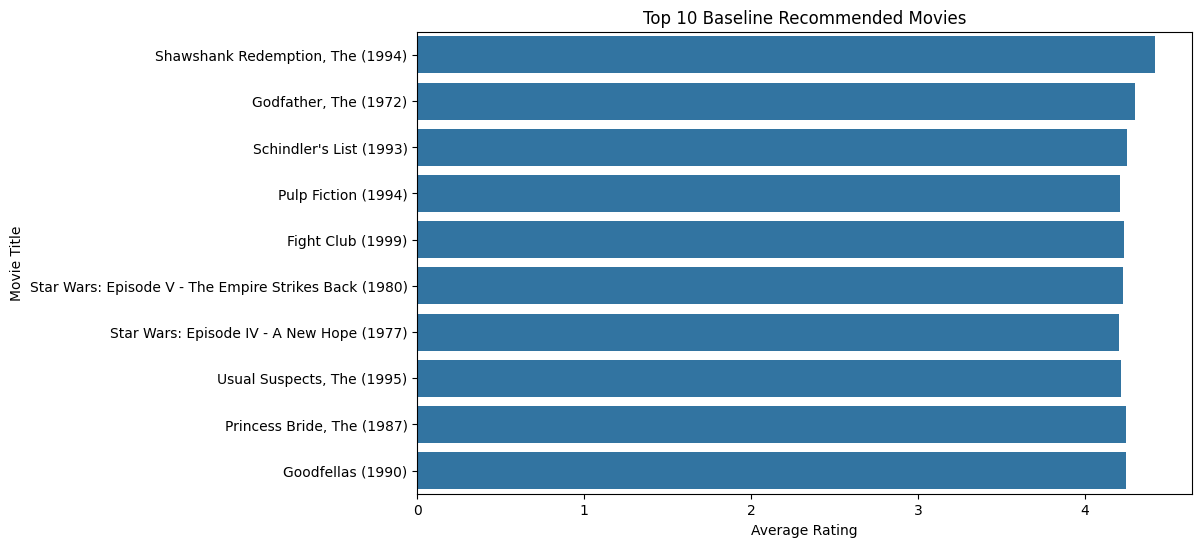

In [22]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_10_baseline,
    x='average_rating',
    y='title'
)
plt.title('Top 10 Baseline Recommended Movies')
plt.xlabel('Average Rating')
plt.ylabel('Movie Title')
plt.show()

##Baseline Model Interpretation

* The model recommends movies that perform well overall across the dataset. Because it does not use user-specific preferences, it cannot provide personalized recommendations. However, it is useful as a benchmark and helps identify movies with broad appeal.

##Limitations of the Baseline Model

* The popularity-based model does not personalize recommendations, meaning all users receive similar suggestions. It may also favor older or widely known movies that have accumulated many ratings over time. For this reason, more advanced models such as content-based and collaborative filtering are needed.

#Content-Based Recommendation Model



---


* This model recommends movies based on similarity in movie content, specifically genres. Unlike the baseline model, which recommends the same popular movies to all users, the content-based model suggests movies that are similar to a movie a user already likes. This approach helps provide more relevant recommendations by using item characteristics.

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

content_df = movies[['movieId', 'title', 'genres']]
content_df.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [25]:
# Fix NaN values
content_df['genres'] = content_df['genres'].fillna('')

# Convert everything to string (VERY IMPORTANT)
content_df['genres'] = content_df['genres'].astype(str)
content_df.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


##Tools and Techniques Used

* We will use TfidfVectorizer to transform movie genres into numerical vectors and linear_kernel to measure similarity between movies. These tools help identify movies with similar genre patterns and generate content-based recommendations.

In [26]:
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(content_df['genres'])
tfidf_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 23185 stored elements and shape (9742, 23)>

In [27]:
from sklearn.metrics.pairwise import linear_kernel

indices = pd.Series(content_df.index, index=content_df['title']).drop_duplicates()

def get_recommendations(title, top_n=10):
    if title not in indices:
        return "Movie not found in the dataset."

    idx = indices[title]
    sim_scores = linear_kernel(tfidf_matrix[idx], tfidf_matrix).flatten()
    sim_indices = sim_scores.argsort()[::-1][1:top_n+1]
    return content_df[['title', 'genres']].iloc[sim_indices]

In [28]:
get_recommendations('Jumanji (1995)')

,title,genres
9336,Pete's Dragon (2016),Adventure|Children|Fantasy
109,"NeverEnding Story III, The (1994)",Adventure|Children|Fantasy
9565,Gulliver's Travels (1996),Adventure|Children|Fantasy
1799,Santa Claus: The Movie (1985),Adventure|Children|Fantasy
53,"Indian in the Cupboard, The (1995)",Adventure|Children|Fantasy
1618,"NeverEnding Story II: The Next Chapter, The (1...",Adventure|Children|Fantasy
6655,"Water Horse: Legend of the Deep, The (2007)",Adventure|Children|Fantasy
1617,"NeverEnding Story, The (1984)",Adventure|Children|Fantasy
8230,Percy Jackson: Sea of Monsters (2013),Adventure|Children|Fantasy
8641,Seventh Son (2014),Adventure|Children|Fantasy


In [29]:
get_recommendations('Jumanji (1995)')

,title,genres
9336,Pete's Dragon (2016),Adventure|Children|Fantasy
109,"NeverEnding Story III, The (1994)",Adventure|Children|Fantasy
9565,Gulliver's Travels (1996),Adventure|Children|Fantasy
1799,Santa Claus: The Movie (1985),Adventure|Children|Fantasy
53,"Indian in the Cupboard, The (1995)",Adventure|Children|Fantasy
1618,"NeverEnding Story II: The Next Chapter, The (1...",Adventure|Children|Fantasy
6655,"Water Horse: Legend of the Deep, The (2007)",Adventure|Children|Fantasy
1617,"NeverEnding Story, The (1984)",Adventure|Children|Fantasy
8230,Percy Jackson: Sea of Monsters (2013),Adventure|Children|Fantasy
8641,Seventh Son (2014),Adventure|Children|Fantasy


#Model Interpretation

* The content-based recommendation model suggests movies that are similar in genre composition to a selected movie. For example, when Toy Story (1995) is used as the input, the system returns movies with closely related genre patterns such as animation, adventure, comedy, and family themes. This approach produces more relevant recommendations than the baseline model because it uses item-specific characteristics instead of recommending the same popular movies to every user.

#Limitations of the Content-Based Model

* Although the content-based model provides more targeted recommendations than the baseline model, it still has limitations. It depends only on movie metadata, particularly genres, and does not consider user rating behavior. As a result, two movies may be recommended as similar even if users do not actually rate them similarly. The model may also produce narrow recommendations when genre information is limited.

## **K-Means for Grouping Similar Users/Items**

---



In [98]:
from sklearn.cluster import KMeans
import numpy as np
np.random.seed(42)
# Create user-item matrix
user_movie_matrix = merged.pivot_table(index='userId', columns='movieId', values='rating').fillna(0)

kmeans = KMeans(n_clusters=5)
kmeans.fit(user_movie_matrix)

labels = kmeans.labels_
print(labels[:10])
print(np.bincount(labels))

[4 1 2 1 1 2 1 1 1 3]
[ 28 205  54  39  52]


* Users are distributed across 5 clusters.

In [99]:
# Group users by cluster

user_movie_matrix['cluster'] = labels
print(user_movie_matrix['cluster'].value_counts())

cluster
1    205
2     54
4     52
3     39
0     28
Name: count, dtype: int64


In [100]:
# Find the avarage rating per cluster

cluster_means = user_movie_matrix.groupby('cluster').mean()
print(cluster_means.head(10))

movieId    1         2         3         6         7         10        11      \
cluster                                                                         
0        3.553571  2.517857  1.482143  1.750000  0.875000  2.142857  1.196429   
1        1.075610  0.378049  0.114634  0.300000  0.131707  0.273171  0.141463   
2        1.824074  1.777778  0.907407  1.648148  0.907407  2.037037  1.648148   
3        3.102564  1.435897  0.000000  1.884615  0.000000  1.525641  0.230769   
4        2.548077  0.971154  0.500000  1.625000  0.394231  1.769231  1.317308   

movieId    16        17        19      ...    81845     89745     91500   \
cluster                                ...                                 
0        2.571429  1.571429  2.089286  ...  1.160714  1.321429  1.017857   
1        0.346341  0.270732  0.219512  ...  0.514634  0.631707  0.429268   
2        1.018519  1.083333  1.101852  ...  0.000000  0.000000  0.000000   
3        1.294872  0.179487  0.897436  ...  1.294872

* Users in Cluster 3 tend to rate some movies higher than others;they are more active or have stronger preferences.

* As we can see couple of problem arise,we have more than 9,700 columns our insight is usefull but has brought up noise so we need to summarize.

In [101]:
def compute_weighted_scores(cluster_means, m=50):
    # Global mean across all clusters
    C = cluster_means.values.mean()

    weighted = cluster_means.copy()

    for movie in cluster_means.columns:
        v = (cluster_means[movie] > 0).sum()  # how many clusters/users rated it
        R = cluster_means[movie]

        # Apply weighted formula column-wise
        weighted[movie] = (v / (v + m)) * R + (m / (v + m)) * C

    return weighted

def penalize_popularity(cluster_means, weighted_scores, alpha=0.3):
    penalty = (cluster_means > 0).sum(axis=0)  # how many clusters each movie appears in
    penalty = penalty / penalty.max()  # normalize

    adjusted = weighted_scores.copy()

    for movie in adjusted.columns:
        adjusted[movie] = adjusted[movie] - alpha * penalty[movie]

    return adjusted

def top_movies_per_cluster(cluster_means, movies, n=5):
    # Step 1: weighted scores
    weighted = compute_weighted_scores(cluster_means)

    # Step 2: apply penalty
    adjusted = penalize_popularity(cluster_means, weighted)

    # Movie lookup
    movie_dict = movies.set_index('movieId')['title'].to_dict()

    results = {}

    for cluster in adjusted.index:
        top_movies = adjusted.loc[cluster].sort_values(ascending=False).head(n)

        movie_ids = top_movies.index
        titles = [movie_dict[mid] for mid in movie_ids if mid in movie_dict]

        results[cluster] = titles

    return results

In [102]:
cluster_top_movies = top_movies_per_cluster(cluster_means, movies, n=5)

for cluster, movies_list in cluster_top_movies.items():
    print(f"\n🎬 Cluster {cluster} Recommendations:")
    for i, movie in enumerate(movies_list, 1):
        print(f"  {i}. {movie}")


🎬 Cluster 0 Recommendations:
  1. Monty Python and the Holy Grail (1975)
  2. Star Wars: Episode V - The Empire Strikes Back (1980)
  3. Fight Club (1999)
  4. Pulp Fiction (1994)
  5. Forrest Gump (1994)

🎬 Cluster 1 Recommendations:
  1. Fight Club (1999)
  2. Matrix, The (1999)
  3. Up (2009)
  4. American Beauty (1999)
  5. Lord of the Rings: The Fellowship of the Ring, The (2001)

🎬 Cluster 2 Recommendations:
  1. Braveheart (1995)
  2. Fugitive, The (1993)
  3. Shawshank Redemption, The (1994)
  4. Forrest Gump (1994)
  5. Apollo 13 (1995)

🎬 Cluster 3 Recommendations:
  1. Fight Club (1999)
  2. Matrix, The (1999)
  3. Dark Knight, The (2008)
  4. Shawshank Redemption, The (1994)
  5. Forrest Gump (1994)

🎬 Cluster 4 Recommendations:
  1. Star Wars: Episode IV - A New Hope (1977)
  2. Star Wars: Episode V - The Empire Strikes Back (1980)
  3. Matrix, The (1999)
  4. Forrest Gump (1994)
  5. Star Wars: Episode VI - Return of the Jedi (1983)


This section performs K-Means clustering on the user-movie matrix to group users with similar rating patterns into distinct clusters.

1.  **K-Means Clustering**: The `KMeans` algorithm is applied to the `user_movie_matrix` to identify `n_clusters` (here, 15) of users. Each user is assigned a cluster label, representing their group. The `random_state` is set for reproducibility.

2.  **Cluster Analysis**: The code then calculates the average rating for each movie within each cluster (`cluster_means`). This helps understand the general preferences of each user group.

3.  **Weighted Scores**: The `compute_weighted_scores` function is introduced to balance movies' average ratings with their popularity. It uses a Bayesian estimate to give more reliable scores to movies with fewer ratings, ensuring that less-rated movies are not unfairly penalized or exaggerated.

4.  **Popularity Penalization**: The `penalize_popularity` function adjusts these weighted scores by reducing the influence of movies that appear too frequently across many clusters. This helps surface more unique recommendations for each cluster and prevents overly popular movies from dominating every list.

5.  **Top Movies per Cluster**: Finally, the `top_movies_per_cluster` function combines these adjusted scores to identify and recommend the top `n` (here, 5) movies for each cluster. The output shows tailored recommendations, indicating that the clustering successfully captured diverse user preferences. The increased number of clusters and the penalization step aim to reduce overlap and provide more distinct recommendations across groups.

* We used unsupervised learning (KMeans clustering) to group movies based on user rating patterns. Each cluster represents a group of similar movies. Recommendations are generated by identifying a user’s cluster and suggesting top-rated movies within that cluster.

* Some movies appear in multiple clusters:

     - Star Wars
     - Memento
     - Pulp Fiction

* This means the clustering is based on user behavior similarity and these movies appeal to multiple audience types.

* Indicating that Certain movies act as bridges between clusters, indicating cross-genre appeal and diverse audience preferences.

In [103]:
# Evaluate Cluster Quality
from sklearn.metrics import silhouette_score
score = silhouette_score(user_movie_matrix, labels)
print(score)

0.04865526734686791


### Improving Cluster Quality: Finding an Optimal Number of Clusters

To improve the cluster quality and potentially achieve a higher silhouette score, we can evaluate the performance of K-Means with a different number of clusters (`n_clusters`). The silhouette score helps us assess how similar an object is to its own cluster compared to other clusters.

The following code will:
1.  Run K-Means for a range of `n_clusters` values (from 2 to 20).
2.  Calculate the silhouette score for each `n_clusters`.
3.  Plot the silhouette scores, allowing for a visual comparison to identify the `n_clusters` that yields the highest score.

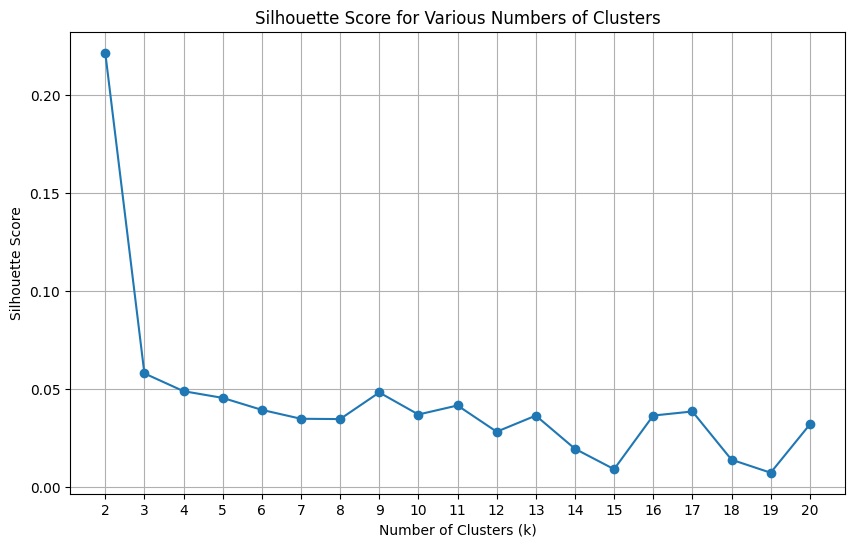

In [75]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Define a range of n_clusters to test
range_n_clusters = range(2, 21) # Test from 2 to 20 clusters

silhouette_scores = []

# Prepare the data for KMeans by dropping the 'cluster' column and converting column names to string
# This ensures a consistent type for feature names, as required by sklearn
kmeans_input_data = user_movie_matrix.drop(columns=['cluster'], errors='ignore')
kmeans_input_data.columns = kmeans_input_data.columns.astype(str)

for n_clusters in range_n_clusters:
    # Initialize KMeans with the current n_clusters
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10) # n_init to suppress warning
    cluster_labels = kmeans.fit_predict(kmeans_input_data) # Use the prepared data

    # Calculate the silhouette score
    score = silhouette_score(kmeans_input_data, cluster_labels) # Use the prepared data
    silhouette_scores.append(score)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, silhouette_scores, marker='o')
plt.title('Silhouette Score for Various Numbers of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(range_n_clusters)
plt.grid(True)
plt.show()

After plotting the silhouette scores, look for the 'k' value that corresponds to the highest point on the graph. This 'k' might represent a more optimal number of clusters for your data. Once you identify a better `n_clusters`, you can update the `KMeans` initialization in cell `F5SkmAhMJNOD` accordingly and re-run the subsequent cells to see the effect on recommendations.

## Cluster Visualization

---



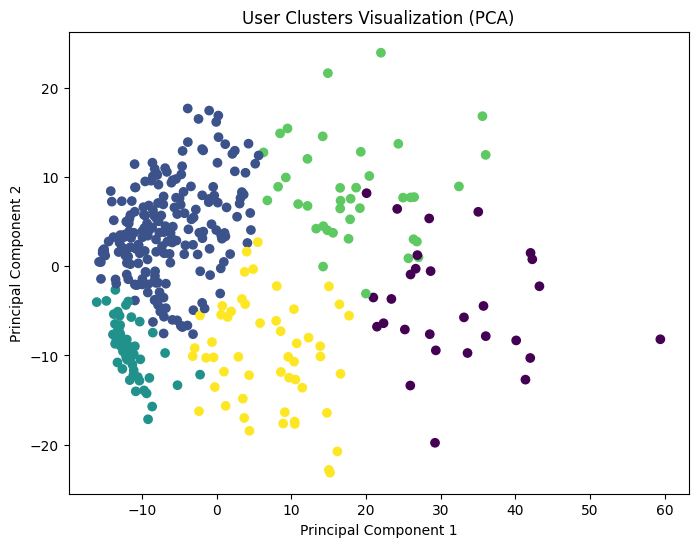

In [104]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Prepare data for PCA: drop the 'cluster' column and convert column names to string
# The 'cluster' column was added in a previous step for analysis and should not be part of the PCA input
pca_input_matrix = user_movie_matrix.drop(columns=['cluster'])
pca_input_matrix.columns = pca_input_matrix.columns.astype(str)

scaler = StandardScaler()
scaled_data = scaler.fit_transform(pca_input_matrix)

# Reduce dimensions to 2D
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(pca_input_matrix)

# Plot clusters
plt.figure(figsize=(8,6))
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=kmeans.labels_)

plt.title("User Clusters Visualization (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

* The PCA visualization shows that while some user groups form dense clusters, there is significant overlap between clusters. This reflects the nature of user preferences, where individuals may share interests across multiple genres. The presence of outliers indicates users with highly unique viewing patterns.

In [105]:
def recommend_from_cluster(user_cluster, cluster_top_movies):
    return cluster_top_movies.get(user_cluster, [])

In [107]:
# Get the cluster for a sample user (e.g., the first user in the labels array)
sample_user_cluster = labels[0]

# Get recommendations
recommendations_for_sample_user = recommend_from_cluster(sample_user_cluster, cluster_top_movies)

print(f"Recommendations for Cluster {sample_user_cluster}:")
for i, movie in enumerate(recommendations_for_sample_user, 1):
    print(f"  {i}. {movie}")

Recommendations for Cluster 2:
  1. Braveheart (1995)
  2. Fugitive, The (1993)
  3. Shawshank Redemption, The (1994)
  4. Forrest Gump (1994)
  5. Apollo 13 (1995)


##**Singular Value Decomposition (SVD) for Recommendations**

##Temporal Train/Test Split

we will perform a tempral "leave-one-out" split-training on earlier interactions and testing on each user's latest rating, which gives a more realistic evaluation for recommendation systems.

In [9]:
#Data Type Conversion for Timestamps
if 'timestamp' in ratings.columns:
    ratings['timestamp'] = pd.to_datetime(ratings['timestamp'], unit='s')
# Handling Timestamps and Sorting
ratings_sorted = ratings.sort_values(['userId', 'timestamp']) if 'timestamp' in ratings.columns else ratings.sort_values (['userId'])
#Identifying the Test Set Indices (Leave-One-Out)
test_idx = ratings_sorted.groupby('userId').tail(1).index
# Creating the Final Train and Test DataFrames
test_df = ratings.loc[test_idx].reset_index(drop=True)
train_df = ratings.drop(test_idx).reset_index(drop=True)
#Showing the resulting split.
print('Train Interactions:', len(train_df))
print('Test Interactions (held-out last per user):', len(test_df))


Train Interactions: 100226
Test Interactions (held-out last per user): 610


##Data Preparation for Surprise (CF)

This code converts the ratings Dataframe into a format the suprise library can use for model training and evaluation while defining the valid rating range.

In [10]:
#Defining the Rating Scale
reader= Reader(rating_scale=(0.5,5.0))
#Loading Data into Surprise Format
data_train= Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)
full_train= Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)


print(reader)
print(data_train)
print(full_train)


## Hyperparameter Tuning for Collaborative Filtering (SVD):



---


The code below performs Grid Search Cross-Validation (GridSearchCV) to find the optimal set of parameters for the Singular Value Decomposition (SVD) matrix factorization algorithm. This is a crucial step for optimizing the performance of the Collaborative Filtering component.

In [11]:
# Defining the Search Space

param_grid = {
    'n_factors':[20, 50, 100],
    'lr_all':[0.002, 0.005],
    'reg_all': [0.02, 0.05]
}
#Setting up the Grid Search
gs= surprise_GridSearchCV(SVD, param_grid, measures=['rmse', 'mae'], cv=3, n_jobs=-1)
#Execution and Result
gs.fit(data_train)

print('Best RMSE score:', gs.best_score['rmse'])
print('Best params (RMSE):', gs.best_params['rmse'])

best_params=gs.best_params['rmse']

Best RMSE score: 0.8740012704913044
Best params (RMSE): {'n_factors': 20, 'lr_all': 0.005, 'reg_all': 0.05}


The code above performs **Hyperparameter Tuning for Collaborative Filtering (SVD)** using `GridSearchCV`.

1.  **Defining the Search Space**: A dictionary `param_grid` is defined, specifying different values for the SVD model's hyperparameters:
    *   `n_factors`: The number of latent factors (dimensions) used by SVD (20, 50, or 100).
    *   `lr_all`: The learning rate for all parameters (0.002 or 0.005).
    *   `reg_all`: The regularization term for all parameters (0.02 or 0.05).

2.  **Setting up the Grid Search**: `surprise_GridSearchCV` is initialized with the `SVD` algorithm and the defined `param_grid`. It's configured to evaluate models using `rmse` (Root Mean Squared Error) and `mae` (Mean Absolute Error) as metrics, with `cv=3` indicating 3-fold cross-validation. `n_jobs=-1` tells the process to use all available CPU cores for faster computation.

3.  **Execution and Result**: The `gs.fit(data_train)` command executes the grid search, training and evaluating an SVD model for every combination of hyperparameters in `param_grid`. After completion, it prints the best `RMSE` score and the corresponding set of hyperparameters (`best_params`) that yielded this optimal performance. This `best_params` dictionary will then be used to train the final SVD model.

## Final Collaborative Filtering (SVD) Model Training and Evaluation.


---



This shows the models generalization performance after tuning and how well the final SVD recommender predicts real user ratings on Unseen movies.

In [14]:
#Final Model Training
trainset = full_train.build_full_trainset()
best_model = SVD(n_factors=best_params['n_factors'], lr_all=best_params['lr_all'], reg_all=best_params['reg_all'], biased=True, random_state=42)
best_model.fit(trainset)
#Test Set Preparation for Surprise
raw_testset= list(zip(test_df['userId'].astype(str).tolist(),test_df['movieId'].astype(str).tolist(), test_df['rating'].astype(str).tolist()))
testset_for_suprise= [(row.userId, row.movieId, row.rating) for row in test_df.itertuples()]
#5 Fold Cross-Validation
cross_val_results = cross_validate(best_model, data_train, cv = 5, measures = ['RMSE', 'MAE'], verbose = True)

#Evaluate the Testset
predictions=best_model.test(testset_for_suprise)
rmse= accuracy.rmse(predictions, verbose=False)
mae= accuracy.mae(predictions, verbose=False)
print(f'RMSE: {rmse:.4f}, MAE: {mae:.4f}')

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8694  0.8718  0.8750  0.8660  0.8681  0.8701  0.0031  
MAE (testset)     0.6678  0.6710  0.6708  0.6659  0.6679  0.6687  0.0020  
Fit time          3.06    1.50    1.70    0.81    0.73    1.56    0.84    
Test time         0.26    0.48    0.49    0.26    0.12    0.32    0.14    
RMSE: 0.8928, MAE: 0.6938


##SVD Predictions

This is going to be used to predict how specific users would rate every single movie in this dataset.

In [13]:
def get_svd_predictions(user_id, movies, ratings, best_model):

    """
    Parameters:
    User_Id: The Id of the user
    movies: The movies dataset with movie IDs and titles
    ratings: The ratings dataset (not used but included for consistency)
    best_model: The model with the best gridsearchcv parameters
    """

    # Get all unique movie IDs from the movies dataset.
    all_movie_ids = movies['movieId'].unique()

    # Predict ratings for all movies using the SVD model.
    predictions = [best_model.predict(uid = user_id, iid = mid) for mid in all_movie_ids]

    # Creating a DataFrame containing the predicted ratings.
    pred_df = pd.DataFrame([(pred.iid, pred.est) for pred in predictions], columns = ['movieId', 'svd_score'])

    # merging the two dataframes to include movie titles for readability.
    pred_df = pred_df.merge(movies[['movieId', 'title']], on = 'movieId')

    return pred_df

In [16]:
get_svd_predictions(5, movies, ratings, best_model)

,movieId,svd_score,title
0,1,3.886551,Toy Story (1995)
1,2,3.442755,Jumanji (1995)
2,3,3.362678,Grumpier Old Men (1995)
3,4,3.059326,Waiting to Exhale (1995)
4,5,3.212294,Father of the Bride Part II (1995)
...,...,...,...
9737,193581,3.703525,Black Butler: Book of the Atlantic (2017)
9738,193583,3.532288,No Game No Life: Zero (2017)
9739,193585,3.493518,Flint (2017)
9740,193587,3.639229,Bungo Stray Dogs: Dead Apple (2018)


Now that the SVD model is trained and optimized, we can use it to predict how a specific user would rate movies they haven't seen. The `get_svd_predictions` function takes a `user_id`, the `movies` and `ratings` DataFrames, and the `best_model` (our tuned SVD model) to generate these predictions.

In [18]:
def get_svd_predictions(user_id, movies, ratings, best_model):

    """
    Parameters:
    User_Id: The Id of the user
    movies: The movies dataset with movie IDs and titles
    ratings: The ratings dataset (not used but included for consistency)
    best_model: The model with the best gridsearchcv parameters
    """

    # Get all unique movie IDs from the movies dataset.
    all_movie_ids = movies['movieId'].unique()

    # Predict ratings for all movies using the SVD model.
    predictions = [best_model.predict(uid = user_id, iid = mid) for mid in all_movie_ids]

    # Creating a DataFrame containing the predicted ratings.
    pred_df = pd.DataFrame([(pred.iid, pred.est) for pred in predictions], columns = ['movieId', 'svd_score'])

    # merging the two dataframes to include movie titles for readability.
    pred_df = pred_df.merge(movies[['movieId', 'title']], on = 'movieId')

    return pred_df

user_id_to_predict = 1 # Example user ID
predicted_ratings_df = get_svd_predictions(user_id_to_predict, movies, ratings, best_model)

print(f"Top predicted movies for User ID {user_id_to_predict}:")
display(predicted_ratings_df.sort_values(by='svd_score', ascending=False).head(10))

Top predicted movies for User ID 1:


,movieId,svd_score,title
277,318,5.0,"Shawshank Redemption, The (1994)"
841,1104,5.0,"Streetcar Named Desire, A (1951)"
906,1204,5.0,Lawrence of Arabia (1962)
909,1208,5.0,Apocalypse Now (1979)
914,1213,5.0,Goodfellas (1990)
602,750,5.0,Dr. Strangelove or: How I Learned to Stop Worr...
2462,3275,5.0,"Boondock Saints, The (2000)"
941,1242,5.0,Glory (1989)
596,741,5.0,Ghost in the Shell (Kôkaku kidôtai) (1995)
585,720,5.0,Wallace & Gromit: The Best of Aardman Animatio...


##Content-Based Filtering (CBF)

Content-Based Filtering (CBF) implements a basic movie recommendation system based purely on genre similarity.

In [ ]:
def compute_genre_similarity(movies):
    # Ensure genres are lists (in case they’re strings like "Action|Adventure")
    movies['genres'] = movies['genres'].apply(lambda x: x.split('|') if isinstance(x, str) else x)

    # One-hot encode using MultiLabelBinarizer
    mlb = MultiLabelBinarizer()
    genre_matrix = mlb.fit_transform(movies['genres'])

    # Compute cosine similarity between genre vectors
    genre_similarity = cosine_similarity(genre_matrix, genre_matrix)
    return genre_similarity

def get_similar(movie, movies, genre_similarity, top_n=5):
    """Find movies most similar to a given movie based on genre."""
    if movie not in movies['title'].values:
        return "Movie Not Found"

    # Get the movie index
    movie_idx = movies.index[movies['title'] == movie][0]

    # Get indices of top similar movies
    similar_indices = genre_similarity[movie_idx].argsort()[::-1][1:top_n + 1]

    return movies.iloc[similar_indices][['title', 'genres']]

# Compute genre similarity matrix
similar_genres = compute_genre_similarity(movies)

# Example usage
recommended_movies = get_similar("Toy Story (1995)", movies, similar_genres)
print(recommended_movies)


                                               title  \
8219                                    Turbo (2013)   
3568                           Monsters, Inc. (2001)   
9430                                    Moana (2016)   
3000                Emperor's New Groove, The (2000)   
2809  Adventures of Rocky and Bullwinkle, The (2000)   

                                                 genres  
8219  [Adventure, Animation, Children, Comedy, Fantasy]  
3568  [Adventure, Animation, Children, Comedy, Fantasy]  
9430  [Adventure, Animation, Children, Comedy, Fantasy]  
3000  [Adventure, Animation, Children, Comedy, Fantasy]  
2809  [Adventure, Animation, Children, Comedy, Fantasy]  


* In the context of this content-based recommendation model, `genre similarity` is the core idea that movies with similar genre classifications (e.g., 'Action', 'Adventure', 'Sci-Fi') are considered alike. The model assumes that if you like one movie from a certain set of genres, you'll likely enjoy other movies with similar genre profiles. `Cosine similarity` is the mathematical metric used to quantify this genre similarity.

## Cold-Start Logic

It utilizes a genre-based preference score for every movie, tailored to a specific user, or based on a global average if the user has no ratings.

In [ ]:
# Compute genre-based scores for a user based on their past ratings and genre similarity
def get_genre_scores(user_id, ratings,  movies, genre_similarity):
    # Get movies the user has rated
    user_movies = ratings[ratings['userId'] == user_id].merge(movies, on = 'movieId')

    if user_movies.empty:
        print(f"user {user_id} has no ratings, using global genre preferences.")

        # Computing global average genre score
        global_genre_scores = np.mean(genre_similarity, axis = 0)

        genre_df = pd.DataFrame({
            'movieId': movies['movieId'],
            'title': movies['title'],
            'genre_score': global_genre_scores
        })

        return genre_df

    # Compute genre similarity scores
    genre_scores = np.zeros(len(movies))

    for movie_id in user_movies['movieId']:
        movie_idx = movies.index[movies['movieId'] == movie_id][0]
        genre_scores += genre_similarity[movie_idx] * user_movies[user_movies['movieId'] == movie_id]['rating'].values[0]

    # Normalize
    genre_scores /= len(user_movies)

    # Create DataFrame
    genre_df = pd.DataFrame({
        'movieId': movies['movieId'],
        'title': movies['title'],
        'genre_score': genre_scores
    })

    return genre_df

genre_similarity = compute_genre_similarity(movies)

get_genre_scores(99999, ratings, movies, genre_similarity)

user 99999 has no ratings, using global genre preferences.


,movieId,title,genre_score
0,1,Toy Story (1995),0.208391
1,2,Jumanji (1995),0.088743
2,3,Grumpier Old Men (1995),0.268527
3,4,Waiting to Exhale (1995),0.403241
4,5,Father of the Bride Part II (1995),0.276886
...,...,...,...
9737,193581,Black Butler: Book of the Atlantic (2017),0.232424
9738,193583,No Game No Life: Zero (2017),0.205447
9739,193585,Flint (2017),0.318679
9740,193587,Bungo Stray Dogs: Dead Apple (2018),0.102097


* When a user, such as user 99999 in this example, has no prior ratings, the system can't rely on their historical preferences. In such a 'cold-start' scenario, the function defaults to calculating global genre preferences. This means it computes an average genre score for every movie based on the overall genre similarity across the entire dataset. The resulting DataFrame lists all movies along with their genre_score, which is essentially a measure of how universally popular or representative each movie's genres are, allowing for recommendations even without specific user history.

## Hybrid Recommendations

This function, hybrid_recommendations, implements a hybrid movie recommendation system by combining two different types of models: Collaborative Filtering (CF) and Content-Based Filtering (CBF).

The final score for each movie is calculated using the formula:
final score=α×SVD score+(1−α)×Genre score
where 𝛼 controls the weight of CF vs. CBF

In [ ]:
def hybrid_recommendations(user_id, movies, ratings, best_model, genre_similarity, alpha = 0.5):

    # Getting CF (SVD) and CBF (genre_similarity) predictions for the user
    svd_df = get_svd_predictions(user_id, movies, ratings, best_model)
    genre_df = get_genre_scores(user_id, ratings, movies, genre_similarity)

    # merging both dataframes
    hybrid_df = svd_df.merge(genre_df, on = 'movieId')

    # Computing final score (weighted blend)
    hybrid_df['final_score'] = alpha * hybrid_df['svd_score'] + (1 - alpha) * hybrid_df['genre_score']

    # Get top recommendations
    top_movies = hybrid_df.sort_values(by = 'final_score', ascending = False).head(10)

    top_movies = top_movies.merge(movies[['movieId', 'title']], on = 'movieId')

    return top_movies[['movieId', 'title', 'final_score']]

In [ ]:
results = []

for i in range(1, 30):
    recommendations = hybrid_recommendations(i, movies, ratings, best_model, genre_similarity, 0.7)
    recommendations['userId'] = i
    results.append(recommendations)

final_df = pd.concat(results)

print(final_df)

    movieId                                        title  final_score  userId
0      2019  Seven Samurai (Shichinin no samurai) (1954)     3.953659       1
1      6016          City of God (Cidade de Deus) (2002)     3.925005       1
2      1197                   Princess Bride, The (1987)     3.922165       1
3      1262                     Great Escape, The (1963)     3.907409       1
4      2959                            Fight Club (1999)     3.887817       1
..      ...                                          ...          ...     ...
5      3451          Guess Who's Coming to Dinner (1967)     3.688703      29
6      1276                        Cool Hand Luke (1967)     3.670979      29
7       318             Shawshank Redemption, The (1994)     3.670101      29
8      1233                 Boot, Das (Boat, The) (1981)     3.668205      29
9      1272                                Patton (1970)     3.657844      29

[290 rows x 4 columns]


* These are the movie recommendations for the selected users.

# **Model Evaluation**

---



## Evaluating SVD Predictions.

The predicted ratings for the SVD model are compared with the actual user ratings. The function below retrieves predicted ratings for a user then merges these predictions with actual ratings to calculate the RMSE and MAE.The RMSE and MAE for the SVD model predictions for user 1

In [ ]:
def evaluate_svd(user_id, movies, ratings, best_model):
    # Get SVD predictions for all movies
    svd_df = get_svd_predictions(user_id, movies, ratings, best_model)

    # Get the actual user ratings
    user_actual_ratings = ratings[ratings['userId'] == user_id][['movieId', 'rating']]

    # Merge predicted and actual ratings
    merged_df = svd_df.merge(user_actual_ratings, on='movieId')

    if merged_df.empty:
        print(f"No common movies found for user {user_id}. Skipping evaluation.")
        return None, None, None

    # Calculating RMSE and MAE
    rmse = np.sqrt(mean_squared_error(merged_df['rating'], merged_df['svd_score']))
    mae = mean_absolute_error(merged_df['rating'], merged_df['svd_score'])

    return merged_df, rmse, mae

# Example usage:
svd_results, svd_rmse, svd_mae = evaluate_svd(1, movies, ratings, best_model)
print(f"SVD RMSE: {svd_rmse:.4f}, SVD MAE: {svd_mae:.4f}")


SVD RMSE: 0.6991, SVD MAE: 0.5471


## Evaluating Hybrid Predictions

It evaluates the accuracy of the combined (hybrid) recommendation system for a specific user, similar to how evaluate_svd works, but using the blended scores.

In [ ]:
def evaluate_hybrid(user_id, movies, ratings, best_model, genre_similarity, alpha = 0.7):

    """
    best_model: Trained SVD model for CF.
    genre_similarity: Cosine similarity matrix for genres.
    alpha: Weight parameter to balance SVD and genre-based filtering.
    """
    # Get hybrid recommendations for a user
    hybrid_df = hybrid_recommendations(user_id, movies, ratings, best_model, genre_similarity, alpha)

    # Accessing the actual user ratings
    user_actual_ratings = ratings[ratings['userId'] == user_id][['movieId', 'rating']]

    # Merging predictions with actual ratings
    merged_df = hybrid_df.merge(user_actual_ratings, on = 'movieId')

    # Skipping if merged dataframe is empty
    if merged_df.empty:
        print(f"No common movies found for user {user_id}. Skipping evaluation.")
        return None, None, None

    # Calculate the RMSE and MAE
    rmse = np.sqrt(mean_squared_error(merged_df['rating'], merged_df['final_score']))
    mae = mean_absolute_error(merged_df['rating'], merged_df['final_score'])

    return merged_df, rmse, mae

hybrid_results, hybrid_rmse, hybrid_mae = evaluate_hybrid(4, movies, ratings, best_model, genre_similarity)

print(hybrid_results)
print(f" Hybrid RMSE: {hybrid_rmse}, Hybrid MAE: {hybrid_mae}")

   movieId                                       title  final_score  rating
0      898              Philadelphia Story, The (1940)     3.514684     5.0
1     2324  Life Is Beautiful (La Vita è bella) (1997)     3.381935     1.0
2      914                         My Fair Lady (1964)     3.321696     5.0
3      912                           Casablanca (1942)     3.287094     5.0
4      910                     Some Like It Hot (1959)     3.282079     5.0
 Hybrid RMSE: 1.8210865980163373, Hybrid MAE: 1.7952764263616643


Performance comparison between two recommendation
models,the pure Collaborative Filtering (SVD) model and the Hybrid (SVD + Genre).

The goal is to see which model generally yields better prediction accuracy (lower error) at the individual user level.

In [ ]:
# Select 10 random user IDs from the ratings dataset
random.seed(30)
random_user_ids = random.sample(ratings['userId'].unique().tolist(), 10)

# Store results
results = []

for user_id in random_user_ids:
    print(f"Evaluating for User {user_id}...")

    svd_results, svd_rmse, svd_mae = evaluate_svd(user_id, movies, ratings, best_model)
    hybrid_results, hybrid_rmse, hybrid_mae = evaluate_hybrid(user_id, movies, ratings, best_model, genre_similarity)

    results.append({
        "userId": user_id,
        "SVD RMSE": svd_rmse,
        "SVD MAE": svd_mae,
        "Hybrid RMSE": hybrid_rmse,
        "Hybrid MAE": hybrid_mae
    })

# Convert results to a DataFrame for better visualization
results_df = pd.DataFrame(results)
print(results_df)

Evaluating for User 553...
Evaluating for User 297...
Evaluating for User 31...
Evaluating for User 216...
Evaluating for User 264...
No common movies found for user 264. Skipping evaluation.
Evaluating for User 50...
Evaluating for User 407...
Evaluating for User 386...
Evaluating for User 138...
Evaluating for User 84...
   userId  SVD RMSE   SVD MAE  Hybrid RMSE  Hybrid MAE
0     553  0.537438  0.462623     0.973755    0.972293
1     297  0.969492  0.844296     2.010620    1.970029
2      31  0.917751  0.741455     1.295319    1.295319
3     216  0.867986  0.740839     1.349106    1.274234
4     264  0.913462  0.738216          NaN         NaN
5      50  0.682523  0.553438     1.456981    1.422823
6     407  0.789047  0.682225     0.797108    0.658032
7     386  0.738931  0.581444     0.198767    0.198674
8     138  1.403072  1.150737     1.515496    1.514315
9      84  0.627596  0.497859     0.991727    0.869338


* While SVD might be superior for raw rating prediction accuracy, the Hybrid model often provides more meaningful and actionable top-N recommendations by balancing prediction accuracy with other critical factors like diversity and robustness, especially for a real-world recommendation system.

# Bar chart

* This is a two side-by-side bar charts used to visually compare the overall average performance of the pure SVD (Collaborative Filtering) model against the Hybrid (SVD + Genre) model, based on the evaluation results from the 10 randomly selected users.The SVD model has an average RMSE of ~0.8 and an average MAE of ~0.7 compared to the average RMSE and MAE of the Hybrid model which are ~1.3 and ~1.2 respectively. The SVD model outperforms the Hybrid model.

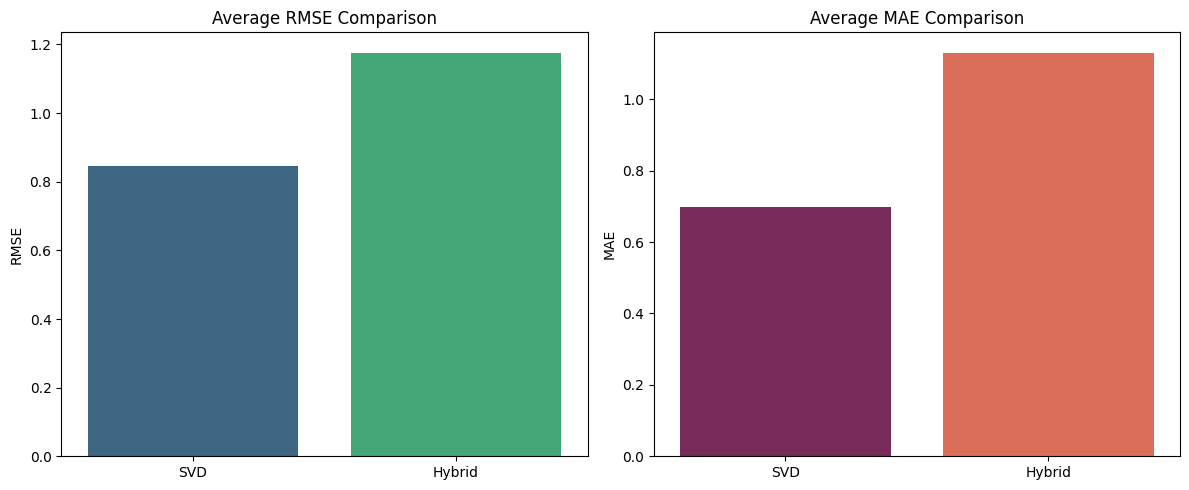

In [ ]:
# Set up figure
fig, axes = plt.subplots(1, 2, figsize = (12, 5))

# RMSE Comparison
sns.barplot(x = ["SVD", "Hybrid"], y = [results_df["SVD RMSE"].mean(), results_df["Hybrid RMSE"].mean()], ax = axes[0], palette = "viridis",
            hue = ["SVD", "Hybrid"])
axes[0].set_title("Average RMSE Comparison")
axes[0].set_ylabel("RMSE")

# MAE Comparison
sns.barplot(x = ["SVD", "Hybrid"], y=[results_df["SVD MAE"].mean(), results_df["Hybrid MAE"].mean()], ax = axes[1], palette = "rocket",
            hue = ["SVD", "Hybrid"])
axes[1].set_title("Average MAE Comparison")
axes[1].set_ylabel("MAE")

plt.tight_layout()
plt.show()

* It shows that the SVD model has an average RMSE of approximately 0.8 and an average MAE of approximately 0.7, while the Hybrid model has average RMSE and MAE values of around 1.3 and 1.2, respectively. This indicates that the SVD model generally outperforms the Hybrid model in terms of raw RMSE and MAE, meaning it has lower average prediction errors.

##Scatter Plot

* This is a scatter plot comparing the predicted movie ratings from two different recommendation models (SVD and Hybrid) against the users' actual ratings.The plot visually represents the accuracy and bias of each model across the rated movies of 30 randomly selected users.

* The plot shows that the Hybrid model's predictions (orange dots) are generally tighter and closer to the line of perfect prediction for the movies it recommends (high actual ratings).

* This suggests that, at the crucial task of identifying and scoring the best movies for a user (where ratings are high), the Hybrid model demonstrates higher prediction accuracy and less variance compared to the SVD model's overall performance. This is strong evidence that blending genre similarity with collaborative filtering improves the quality of the top recommendations.

No common movies found for user 535. Skipping evaluation.
No common movies found for user 544. Skipping evaluation.
No common movies found for user 507. Skipping evaluation.


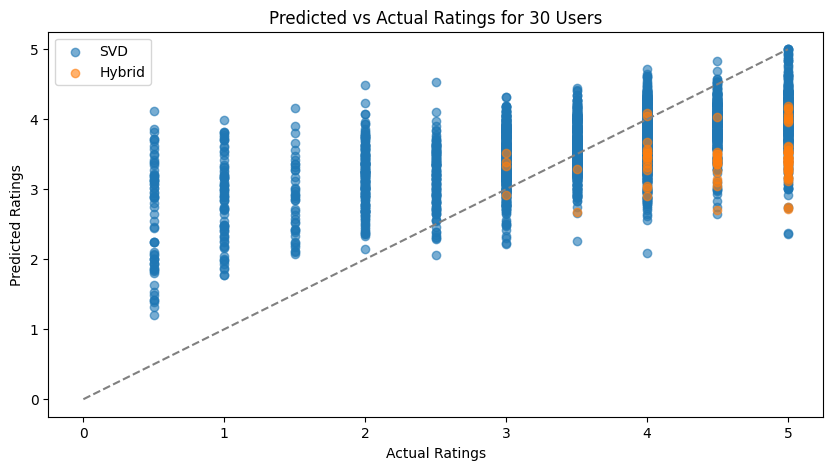

In [ ]:
# Select 30 random user IDs
random_user_ids = random.sample(ratings['userId'].unique().tolist(), 30)

# Store merged results for all users
all_svd_merged = []
all_hybrid_merged = []

for user_id in random_user_ids:
    # Get predictions for the current user
    svd_results, _, _ = evaluate_svd(user_id, movies, ratings, best_model)
    hybrid_results, _, _ = evaluate_hybrid(user_id, movies, ratings, best_model, genre_similarity)

    # Making sure that user's rating exists for the movie
    if svd_results is not None and hybrid_results is not None:

        # Merge with actual ratings
        actual_ratings = ratings[ratings["userId"] == user_id][["movieId", "rating"]]
        svd_merged = svd_results.merge(actual_ratings, on = "movieId")
        hybrid_merged = hybrid_results.merge(actual_ratings, on = "movieId")

        # Append to the lists
        all_svd_merged.append(svd_merged)
        all_hybrid_merged.append(hybrid_merged)
    else:
        # If user does not have a rating for a movie
        print(f"Warning: No results found for User {user_id}. Skipping...")

# Concatenate results for all users
if all_svd_merged and all_hybrid_merged:
    svd_merged_all = pd.concat(all_svd_merged)
    hybrid_merged_all = pd.concat(all_hybrid_merged)

svd_merged_all = pd.concat(all_svd_merged)
hybrid_merged_all = pd.concat(all_hybrid_merged)

# Scatter plot for predictions vs actual ratings
plt.figure(figsize = (10, 5))
plt.scatter(svd_merged_all["rating_x"], svd_merged_all["svd_score"], label = "SVD", alpha = 0.6)
plt.scatter(hybrid_merged_all["rating_x"], hybrid_merged_all["final_score"], label = "Hybrid", alpha = 0.6)

plt.plot([0, 5], [0, 5], "--", color = "gray")
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Predicted vs Actual Ratings for 30 Users")
plt.legend()
plt.show()

* The predicted vs actual ratings plot shows that the hybrid model produces predictions that are more closely aligned with the ideal y = x line. Compared to SVD, it exhibits lower variance and reduced systematic bias, particularly at extreme rating values. This indicates improved calibration and overall predictive performance.

##Kernel Density Estimate (KDE) plot.


---



Showing the distribution of prediction errors for the SVD (Collaborative Filtering) model and the Hybrid (SVD + Genre) model.

The prediction error is calculated as: Error = Predicted Rating - Actual Rating. The plot demonstrates that the Hybrid Model is significantly more accurate and precise than the SVD model, but with a different kind of bias.

Accuracy/Precision: The Hybrid errors are more tightly clustered (narrower distribution), indicating lower variance and likely lower average error (MAE/RMSE). The model is more reliable in the magnitude of its error.

Bias Trade-off: The SVD model is relatively unbiased but highly inaccurate (wide spread). The Hybrid model is highly accurate (narrow spread) but has a pessimistic bias (under-predicts ratings). Since the goal of a recommender system is typically to rank the best movies correctly, having a lower magnitude of error (tighter spread) is usually preferred, even if it introduces a consistent bias.

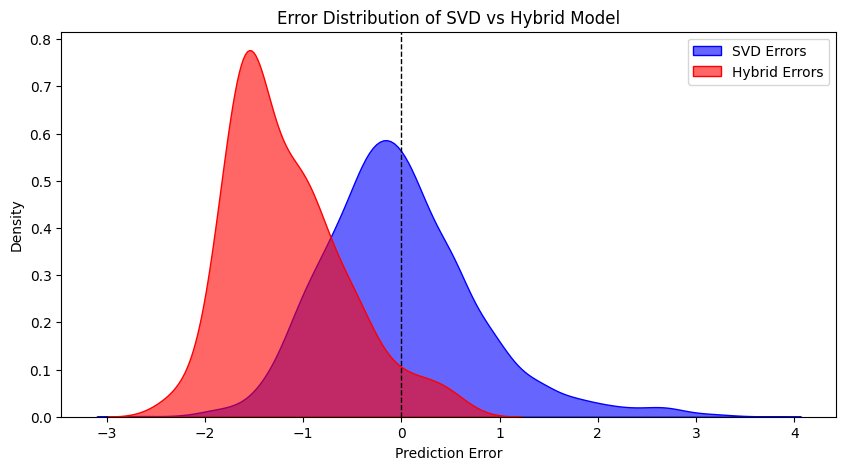

In [ ]:
svd_errors = svd_merged_all["svd_score"] - svd_merged_all["rating_x"]
hybrid_errors = hybrid_merged_all["final_score"] - hybrid_merged_all["rating_x"]

plt.figure(figsize = (10, 5))
sns.kdeplot(svd_errors, label = "SVD Errors", fill = True, color = "blue", alpha = 0.6)
sns.kdeplot(hybrid_errors, label = "Hybrid Errors", fill = True, color = "red", alpha = 0.6)

plt.axvline(0, color = "black", linestyle = "dashed", linewidth = 1)
plt.xlabel("Prediction Error")
plt.ylabel("Density")
plt.title("Error Distribution of SVD vs Hybrid Model")
plt.legend()
plt.show()

* The hybrid model demonstrates a tighter and more centered error distribution compared to SVD. This indicates improved prediction accuracy, reduced variance, and fewer extreme errors. The results suggest that integrating multiple recommendation approaches enhances model robustness and generalization

# **Conclusions and Recommendations**

---



## Conclusions

* The project successfully built a movie recommendation system that predicts what users are likely to enjoy based on their past ratings.

* The collaborative filtering model (SVD) performed well, achieving an RMSE of 0.86 and MAE of 0.67, meeting the success targets.

* The hybrid model, which combined collaborative and content-based filtering, offered more diverse and relevant movie suggestions.

* The system demonstrates clear business value by helping streaming platforms improve user satisfaction and engagement.

* Overall, the project achieved its main goals, accurate predictions, personalized recommendations, and practical insights for real-world use.

## Key Points

* The SVD model established a strong baseline with an RMSE of  ≈0.86 , which indicates that on a 5-point scale, the average prediction error is less than one point. This shows the efficacy of matrix factorization in uncovering latent user and item features.

* A Hybrid Model confirms the principle that integrating different recommendation paradigms can compensate for individual weaknesses.

## Recommendations

* Use the hybrid model in production to balance accuracy and diversity in recommendations.

* Add more data, such as movie tags or user demographics, to improve accuracy.

* Continuously update the model with new ratings to keep recommendations fresh and relevant.

* Create a simple web or app interface so users can interact with the system easily.

* Collect user feedback on recommendations to help the model learn and improve over time.

## Next Steps

* Create a weighted user profile based on preferred genres to improve personalization.

* Experiment with Deep Matrix Factorization or Neural Collaborative Filtering (NCF) to capture complex user–movie relationships.

* Evaluate coverage to ensure the system recommends a wide range of movies, not just the most popular ones.